<a href="https://colab.research.google.com/github/smsag99/Thesis/blob/main/codes/FeatureEng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Animal Data


Load the dataset from '/content/drive/MyDrive/Thesis_Data/Dati_ok.txt' into a pandas DataFrame.


In [ ]:
datasetAnimalPath = '/content/drive/MyDrive/Thesis_Data/Dati_ok.txt'

In [ ]:
import pandas as pd

# 1. Define your column names
col_names = [
    'Farm_Code', 'Animal_ID', 'dtb', 'dtc', 'dtt',
    'parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM'
]

cleaned_rows = []

# 2. Read and clean the file line by line
with open(datasetAnimalPath, 'r') as file:
    # Skip the header line
    next(file)

    for line in file:
        # Remove whitespace/newlines from ends
        line = line.strip()

        # Skip empty lines if any exist
        if not line:
            continue

        # Split the line by comma
        parts = line.split(',')

        # LOGIC: Fix the rows based on length
        if len(parts) == 11:
            # This is a correct row, keep it as is
            cleaned_rows.append(parts)

        elif len(parts) == 12:
            # This is a broken row.
            # This leaves one empty slot for 'dtb' and shifts the rest back.
            parts.pop(2)
            cleaned_rows.append(parts)

# 3. Create the DataFrame
df_animal = pd.DataFrame(cleaned_rows, columns=col_names)

# 4. Convert columns to correct types (since they were read as strings)
numeric_cols = ['Farm_Code','parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM']
for col in numeric_cols:
    df_animal[col] = pd.to_numeric(df_animal[col], errors='coerce')

# 5. Convert Date Columns
date_cols = ['dtb', 'dtc', 'dtt']
for col in date_cols:
    df_animal[col] = pd.to_datetime(df_animal[col], format='%Y%m%d', errors='coerce')

# Check the result
print(df_animal.head(5))
print(f"\nTotal rows loaded: {len(df_animal)}")

   Farm_Code       Animal_ID        dtb        dtc        dtt  parity  \
0     521513  IT003990094624 2013-10-29 2022-06-07 2022-06-20       6   
1     521513  IT003990094624 2013-10-29 2022-06-07 2022-07-19       6   
2     521513  IT003990094624 2013-10-29 2022-06-07 2022-09-12       6   
3     521513  IT003990094624 2013-10-29 2022-06-07 2022-10-13       6   
4     521513  IT003990094624 2013-10-29 2022-06-07 2022-11-15       6   

   milk_kg  fat_p  protein_p  cells  NM  
0      141    617        484    656   2  
1      168    682        417    827   2  
2      134    763        459   1144   2  
3      108    663        454   1403   2  
4       94    688        451   1805   2  

Total rows loaded: 2593267


### Scaling the Numeric Data

In [ ]:
len(df_animal[df_animal['cells']==0])

118300

In [ ]:
df_animal[df_animal['cells']==0] = 1

/tmp/ipykernel_8179/2044939430.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df_animal[df_animal['cells']==0] = 1
/tmp/ipykernel_8179/2044939430.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df_animal[df_animal['cells']==0] = 1
/tmp/ipykernel_8179/2044939430.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df_animal[df_animal['cells']==0] = 1


In [ ]:
df_animal['milk_kg'] = df_animal['milk_kg'] /10
df_animal['fat_p'] = df_animal['fat_p'] / 100
df_animal['protein_p'] = df_animal['protein_p'] / 100
# df_animal['cells'] = df_animal['cells'] * 100000

### Adding ECM, AFC, SCS, DIM
#### Variable Calculations

**Energy-Corrected Milk (ECM)**
Buffalo-specific formula:
$$ECM = \left( \left[ \left( (Fat \times 10) - 40 \right) + \left( (Protein \times 10) - 31 \right) \right] \times 0.01155 + 1 \right) \times milk$$

**Somatic Cell Score (SCS)**
Conversion to linear score:
$$SCS = \log_{2}\left(\frac{Cells}{100}\right) + 3$$

**Age at First Calving (AFC)**
$$AFC = DTC - DTB$$

**Days in Milk (DIM)**
$$DIM = DTT - DTC$$

In [ ]:
import numpy as np
df_animal['ECM'] = (((((df_animal['fat_p'] * 10) - 40) + ((df_animal['protein_p'] * 10) - 31)) * 0.01155) + 1) * df_animal['milk_kg']
df_animal['SCS'] = np.log2((df_animal['cells']) / 100) + 3
df_animal['AFC'] = df_animal['dtc'] - df_animal['dtb']
df_animal['DIM'] = df_animal['dtt'] - df_animal['dtc']

### Removing Outliers
####1. Component Thresholds
$$
\text{milk} =
\begin{cases}
\text{remove} & \text{if } \text{milk} \le 0.40 \text{ or } \text{milk} \ge 26.50 \\
\text{milk} & \text{otherwise}
\end{cases}
$$

$$
\text{fat} =
\begin{cases}
\text{remove} & \text{if } \text{fat} \le 1.60 \text{ or } \text{fat} \ge 15.05 \\
\text{fat} & \text{otherwise}
\end{cases}
$$

$$
\text{protein} =
\begin{cases}
\text{remove} & \text{if } \text{protein} \le 2.67 \text{ or } \text{protein} \ge 6.68 \\
\text{protein} & \text{otherwise}
\end{cases}
$$

$$
\text{SCS} =
\begin{cases}
\text{remove} & \text{if } \text{SCS} \le -2.06 \text{ or } \text{SCS} \ge 10.73 \\
\text{SCS} & \text{otherwise}
\end{cases}
$$

#### 2. ECM Logic
$$
\text{ECM} =
\begin{cases}
\text{remove} & \text{if } (\text{milk}, \text{fat}, \text{or protein}) = 0 \\
\text{remove} & \text{if } \text{ECM} \ge 30 \\
\text{ECM} & \text{otherwise}
\end{cases}
$$

#### 3. Inclusion Criteria (Days)
$$720 \le \text{AFC} \le 1440$$

In [ ]:
df_animal_filtered = df_animal[(df_animal['milk_kg'] >= 0.4) & (df_animal['milk_kg'] <= 26.5)]
print(f"Total rows removed after milk filtering: {len(df_animal)-len(df_animal_filtered)}")
df_animal_filtered = df_animal_filtered[(df_animal_filtered['fat_p'] >= 1.6) & (df_animal_filtered['fat_p'] <= 15.05)]
print(f"Total rows removed after fat filtering: {len(df_animal)-len(df_animal_filtered)}")
df_animal_filtered = df_animal_filtered[(df_animal_filtered['protein_p'] >= 2.67) & (df_animal_filtered['protein_p'] <= 6.68)]
print(f"Total rows removed after protein filtering: {len(df_animal)-len(df_animal_filtered)}")
df_animal_filtered = df_animal_filtered[(df_animal_filtered['SCS'] >= -2.06) & (df_animal_filtered['SCS'] <= 10.73)]
print(f"Total rows removed after SCS filtering: {len(df_animal)-len(df_animal_filtered)}")
df_animal_filtered = df_animal_filtered[df_animal_filtered['ECM'] <= 301]
print(f"Total rows removed after ECM filtering: {len(df_animal)-len(df_animal_filtered)}")
df_animal_filtered = df_animal_filtered[(df_animal_filtered['AFC'] >= pd.Timedelta(days=720)) & (df_animal_filtered['AFC'] <= pd.Timedelta(days=1440))]
print(f"Total rows removed after AFC filtering: {len(df_animal)-len(df_animal_filtered)}")

Total rows removed after milk filtering: 119910
Total rows removed after fat filtering: 151175
Total rows removed after protein filtering: 153274
Total rows removed after SCS filtering: 155151
Total rows removed after ECM filtering: 155151
Total rows removed after AFC filtering: 1866833


In [ ]:
(len(df_animal)-len(df_animal_filtered))

1866833

### Parameters Analysis after outlier removal

Generating data visualizations for numerical columns...


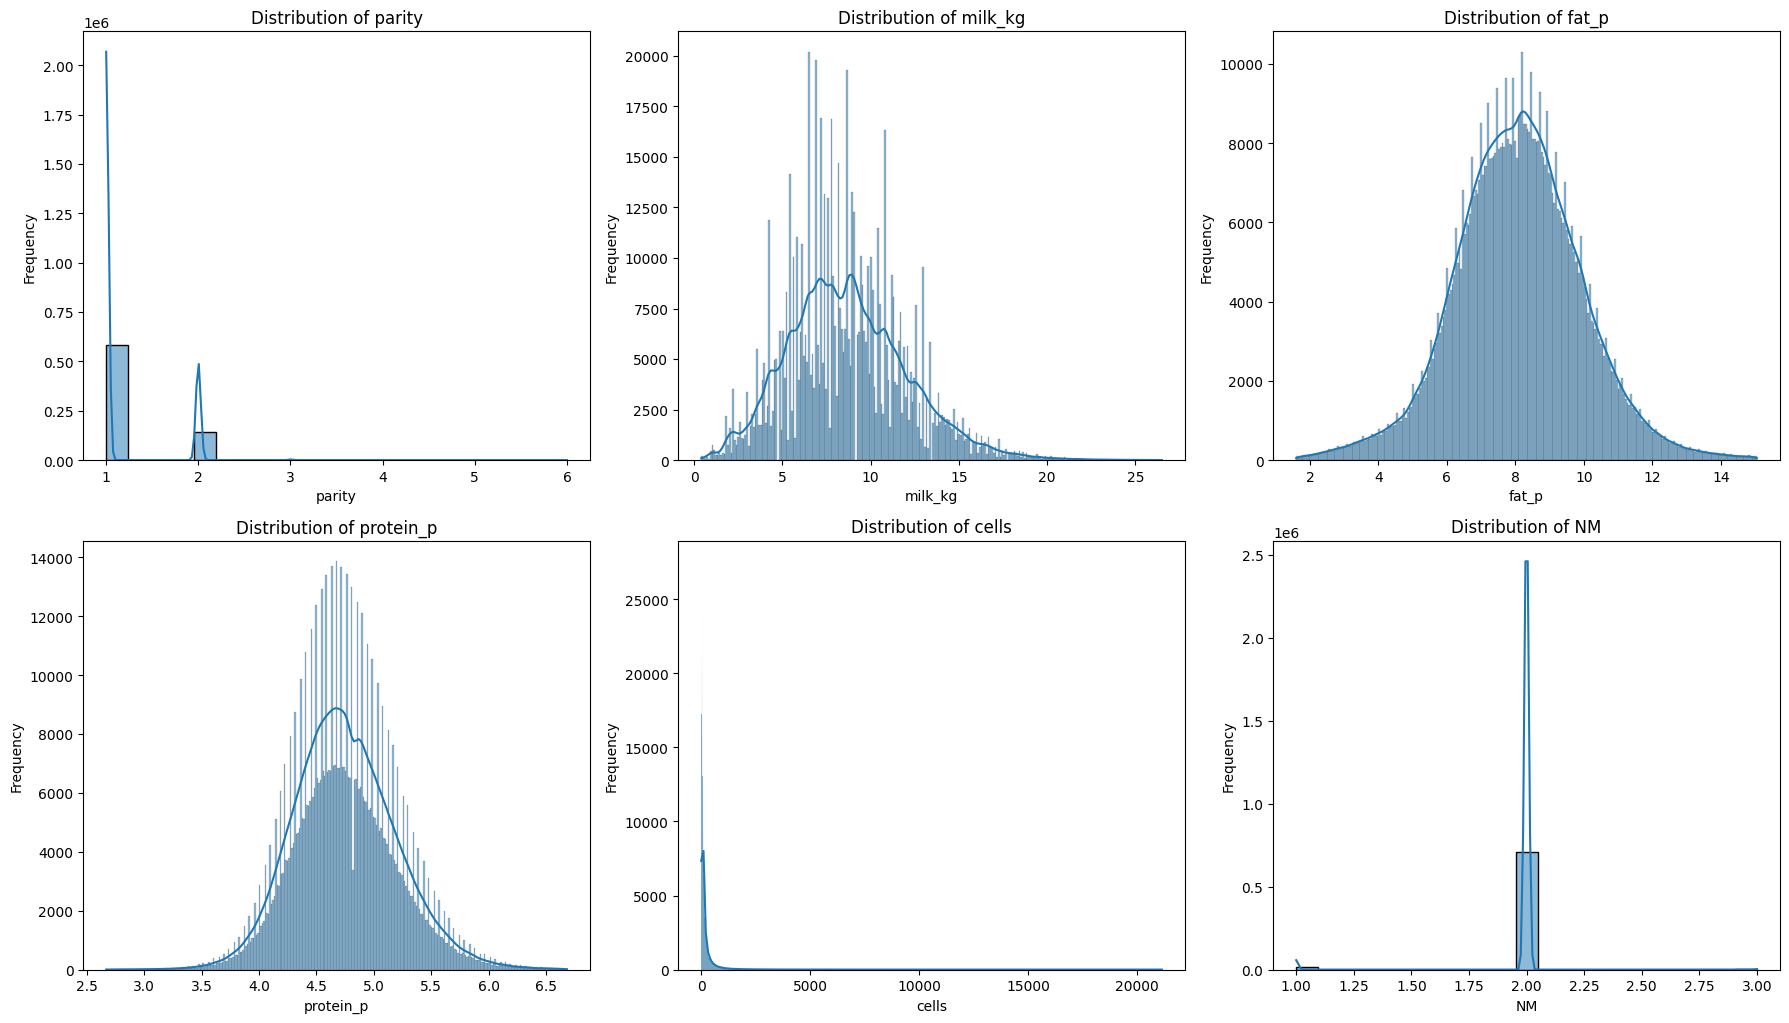

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating data visualizations for numerical columns...")

# Set up the matplotlib figure and axes for subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten() # Flatten the 3x3 array of axes for easy iteration

# Select numerical columns for visualization, excluding date-like integers and IDs
numerical_cols = ['parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM']

# Create histograms for numerical columns
for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.histplot(df_animal_filtered[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## process farm weather to daily


In [ ]:
import pandas as pd

df_farm_weather = pd.read_csv('/content/drive/MyDrive/Thesis_Data/farm_weather_data/farm_5600132.0_weather.csv')


In [ ]:
import pandas as pd
import os
from pathlib import Path

def process_farm_weather_to_daily(input_folder, output_folder):

    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    # Get all CSV files in the input folder
    csv_files = list(Path(input_folder).glob("*weather.csv"))

    if not csv_files:
        print(f"No CSV files found in {input_folder}")
        return

    print(f"Found {len(csv_files)} farm weather file(s) to process\n")
    print("="*70)

    # Process each file
    for csv_file in csv_files:
        try:
            print(f"\nProcessing: {csv_file.name}")

            # Read the CSV file
            df = pd.read_csv(csv_file)

            # Convert time column to datetime
            df['time'] = pd.to_datetime(df['time'])

            # Extract date for grouping
            df['date'] = df['time'].dt.date

            # Group by date and calculate daily aggregates
            daily_agg = df.groupby('date').agg({
                'temperature_2m': ['mean', 'max', 'min'],
                'relative_humidity_2m': ['mean', 'max', 'min'],
                'wind_speed_10m': ['mean', 'max', 'min']
            }).reset_index()

            # Flatten column names
            daily_agg.columns = [
                'date',
                'temperature_avg', 'temperature_max', 'temperature_min',
                'humidity_avg', 'humidity_max', 'humidity_min',
                'wind_speed_avg', 'wind_speed_max', 'wind_speed_min'
            ]

            # Round to reasonable precision
            numeric_cols = daily_agg.columns[1:]  # All columns except 'date'
            daily_agg[numeric_cols] = daily_agg[numeric_cols].round(3)

            # Create output filename - extract farm ID from original name
            # Handle both formats: farm_XXXXX_0_weather.csv and farm_XXXXX.0_weather.csv
            base_name = csv_file.stem.replace('_weather', '')
            output_filename = base_name + '_daily.csv'
            output_path = os.path.join(output_folder, output_filename)

            # Save to CSV
            daily_agg.to_csv(output_path, index=False)

        except Exception as e:
            print(f"  ✗ Error processing {csv_file.name}: {str(e)}\n")
            continue

    print("\n" + "="*70)
    print(f"✓ Processing complete!")
    print(f"✓ Daily aggregate files saved to: {output_folder}")
    print("="*70)



# Set your paths here
input_folder = "/content/drive/MyDrive/Thesis_Data/farm_weather_data(Temperature_Humidity_Wind)"
output_folder = "/content/drive/MyDrive/Thesis_Data/farm_weather_daily2"

process_farm_weather_to_daily(input_folder, output_folder)

Found 329 farm weather file(s) to process


Processing: farm_7002559.0_weather.csv

Processing: farm_2245202.0_weather.csv

Processing: farm_6800106.0_weather.csv

Processing: farm_7000464.0_weather.csv

Processing: farm_7002551.0_weather.csv

Processing: farm_6800052.0_weather.csv

Processing: farm_2750207.0_weather.csv

Processing: farm_7000211.0_weather.csv

Processing: farm_6800274.0_weather.csv

Processing: farm_6811606.0_weather.csv

Processing: farm_9330905.0_weather.csv

Processing: farm_6811505.0_weather.csv

Processing: farm_4241329.0_weather.csv

Processing: farm_6811588.0_weather.csv

Processing: farm_5600136.0_weather.csv

Processing: farm_6812804.0_weather.csv

Processing: farm_5744453.0_weather.csv

Processing: farm_6330323.0_weather.csv

Processing: farm_6810135.0_weather.csv

Processing: farm_2750230.0_weather.csv

Processing: farm_7050107.0_weather.csv

Processing: farm_6800152.0_weather.csv

Processing: farm_6811752.0_weather.csv

Processing: farm_6800465.0_weather.c

## calculate weather indices (THI,WHI)

In [ ]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

def calculate_weather_indices(input_folder, output_folder):

    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    # Get all daily CSV files
    csv_files = list(Path(input_folder).glob("*_daily.csv"))

    if not csv_files:
        print(f"No daily CSV files found in {input_folder}")
        return

    print(f"Found {len(csv_files)} daily weather file(s) to process\n")
    print("="*70)

    # Process each file
    for csv_file in csv_files:
        try:
            print(f"\nProcessing: {csv_file.name}")

            # Read the daily CSV file
            df = pd.read_csv(csv_file)

            # Extract variables for calculations
            T_avg = df['temperature_avg']
            RH_avg = df['humidity_avg']
            ws_avg = df['wind_speed_avg']
            T_min = df['temperature_min']
            RH_min = df['humidity_min']
            ws_min = df['wind_speed_min']
            T_max = df['temperature_max']
            RH_max = df['humidity_max']
            ws_max = df['wind_speed_max']

            # Calculate THI_1
            # THI_1 = (1.8*T+32) - ((0.55-0.0055*RH)*(1.8*T-26))
            df['THI_1_avg'] = (1.8 * T_avg + 32) - ((0.55 - 0.0055 * RH_avg) * (1.8 * T_avg - 26))
            df['THI_1_min'] = (1.8 * T_min + 32) - ((0.55 - 0.0055 * RH_min) * (1.8 * T_min - 26))
            df['THI_1_max'] = (1.8 * T_max + 32) - ((0.55 - 0.0055 * RH_max) * (1.8 * T_max - 26))

            # Calculate THI_2
            # THI_2 = (1.8*T) - (1-RH/100)*(T-14.3) + 32
            df['THI_2_avg'] = (1.8 * T_avg) - (1 - RH_avg/100) * (T_avg - 14.3) + 32
            df['THI_2_min'] = (1.8 * T_min) - (1 - RH_min/100) * (T_min - 14.3) + 32
            df['THI_2_max'] = (1.8 * T_max) - (1 - RH_max/100) * (T_max - 14.3) + 32

            # Calculate WHI
            # WHI = 33 - (33-T)*(0.474266 + 0.453843*sqrt(ws) - 0.0453843*ws)
            df['WHI_avg'] = 33 - (33 - T_avg) * (0.474266 + 0.453843 * np.sqrt(ws_avg) - 0.0453843 * ws_avg)
            df['WHI_min'] = 33 - (33 - T_min) * (0.474266 + 0.453843 * np.sqrt(ws_min) - 0.0453843 * ws_min)
            df['WHI_max'] = 33 - (33 - T_max) * (0.474266 + 0.453843 * np.sqrt(ws_max) - 0.0453843 * ws_max)

            # Round indices to 3 decimal places
            df['THI_1_avg'] = df['THI_1_avg'].round(3)
            df['THI_1_min'] = df['THI_1_min'].round(3)
            df['THI_1_max'] = df['THI_1_max'].round(3)

            df['THI_2_avg'] = df['THI_2_avg'].round(3)
            df['THI_2_min'] = df['THI_2_min'].round(3)
            df['THI_2_max'] = df['THI_2_max'].round(3)

            df['WHI_avg'] = df['WHI_avg'].round(3)
            df['WHI_min'] = df['WHI_min'].round(3)
            df['WHI_max'] = df['WHI_max'].round(3)

            # Create output filename
            base_name = csv_file.stem.replace('_daily', '')
            output_filename = base_name + '_with_indices.csv'
            output_path = os.path.join(output_folder, output_filename)

            # Save to CSV
            df.to_csv(output_path, index=False)

            print(f"  ✓ Created: {output_filename}")
            print(f"    Total records: {len(df):,}")
            print(f"    Date range: {df['date'].min()} to {df['date'].max()}")

        except Exception as e:
            print(f"  ✗ Error processing {csv_file.name}: {str(e)}\n")
            import traceback
            traceback.print_exc()
            continue

    print("\n" + "="*70)
    print(f"✓ Index calculation complete!")
    print(f"✓ Files with indices saved to: {output_folder}")
    print("="*70)



# Set your paths here
input_folder = "/content/drive/MyDrive/Thesis_Data/farm_weather_daily2"       # Where daily files are
output_folder = "/content/drive/MyDrive/Thesis_Data/farm_weather_indices2"    # Where to save files with indices

calculate_weather_indices(input_folder, output_folder)

Found 329 daily weather file(s) to process


Processing: farm_7002559.0_daily.csv
  ✓ Created: farm_7002559.0_with_indices.csv
    Total records: 4,749
    Date range: 2012-12-31 to 2025-12-31

Processing: farm_2245202.0_daily.csv
  ✓ Created: farm_2245202.0_with_indices.csv
    Total records: 4,749
    Date range: 2012-12-31 to 2025-12-31

Processing: farm_6800106.0_daily.csv
  ✓ Created: farm_6800106.0_with_indices.csv
    Total records: 4,749
    Date range: 2012-12-31 to 2025-12-31

Processing: farm_7000464.0_daily.csv
  ✓ Created: farm_7000464.0_with_indices.csv
    Total records: 4,749
    Date range: 2012-12-31 to 2025-12-31

Processing: farm_7002551.0_daily.csv
  ✓ Created: farm_7002551.0_with_indices.csv
    Total records: 4,749
    Date range: 2012-12-31 to 2025-12-31

Processing: farm_6800052.0_daily.csv
  ✓ Created: farm_6800052.0_with_indices.csv
    Total records: 4,749
    Date range: 2012-12-31 to 2025-12-31

Processing: farm_2750207.0_daily.csv
  ✓ Created: farm_275020

## Merginf all the data together

In [10]:
import pandas as pd
import os
from pathlib import Path
from datetime import datetime

def merge_animal_weather_data(animal_file, weather_folder, output_file):
    """
    Merge animal data with farm-specific weather data based on Farm_Code and dtt date.

    Parameters:
    - animal_file: Path to the animal data CSV file
    - weather_folder: Path to folder containing farm weather files (farm_XXXXX.0_with_indices.csv)
    - output_file: Path where the merged data will be saved
    """

    print("="*80)
    print("MERGING ANIMAL DATA WITH WEATHER DATA")
    print("="*80)

    # Read the animal data
    print(f"\n1. Reading animal data from: {animal_file}")
    animal_df = pd.read_csv(animal_file)
    print(f"   ✓ Loaded {len(animal_df):,} animal records")
    print(f"   ✓ Columns: {list(animal_df.columns)}")

    # Convert dtt to datetime (just the date part for matching)
    print(f"\n2. Converting 'dtt' column to date format...")
    animal_df['dtt_date'] = pd.to_datetime(animal_df['dtt'], format='mixed', errors='coerce').dt.date

    # Check for any dates that couldn't be parsed
    null_dates = animal_df['dtt_date'].isnull().sum()
    if null_dates > 0:
        print(f"   ⚠ Warning: {null_dates:,} records have invalid dates and will be skipped")

    # Get unique farm codes
    unique_farms = animal_df['Farm_Code'].unique()
    print(f"   ✓ Found {len(unique_farms)} unique farms in animal data")
    print(f"   ✓ Farm codes: {sorted(unique_farms)}")

    # Load all weather files into a dictionary
    print(f"\n3. Loading weather data files from: {weather_folder}")
    weather_data = {}
    weather_files = list(Path(weather_folder).glob("farm_*_with_indices.csv"))

    if not weather_files:
        print(f"   ✗ ERROR: No weather files found in {weather_folder}")
        print(f"   ✗ Looking for files matching pattern: farm_*_with_indices.csv")
        return

    print(f"   ✓ Found {len(weather_files)} weather files")

    for weather_file in weather_files:
        try:
            # Extract farm code from filename
            # Filename format: farm_521513.0_with_indices.csv or similar
            filename = weather_file.stem  # e.g., 'farm_521513.0_with_indices'
            parts = filename.split('_')

            # Find the farm code (numeric part after 'farm_')
            farm_code = None
            for part in parts[1:]:  # Skip 'farm'
                # Remove '.0' if present and check if it's numeric
                clean_part = part.replace('.0', '').replace('.', '')
                if clean_part.isdigit():
                    farm_code = int(clean_part)
                    break

            if farm_code is None:
                print(f"   ⚠ Warning: Could not extract farm code from {weather_file.name}")
                continue

            # Read weather data
            weather_df = pd.read_csv(weather_file)

            # Convert date column to date format
            weather_df['date'] = pd.to_datetime(weather_df['date']).dt.date

            # Store in dictionary with farm_code as key
            weather_data[farm_code] = weather_df

            print(f"   ✓ Loaded farm {farm_code}: {len(weather_df)} daily records "
                  f"({weather_df['date'].min()} to {weather_df['date'].max()})")

        except Exception as e:
            print(f"   ✗ Error loading {weather_file.name}: {str(e)}")
            continue

    print(f"\n   ✓ Successfully loaded weather data for {len(weather_data)} farms")

    # Check which farms in animal data have weather data
    farms_with_weather = set(weather_data.keys())
    farms_in_animal = set(unique_farms)
    farms_missing_weather = farms_in_animal - farms_with_weather

    if farms_missing_weather:
        print(f"\n   ⚠ WARNING: {len(farms_missing_weather)} farms in animal data don't have weather files:")
        print(f"   Missing: {sorted(farms_missing_weather)}")

    # Merge weather data with animal data
    print(f"\n4. Merging animal data with weather data...")

    # Initialize columns for weather data
    weather_columns = []
    if len(weather_data) > 0:
        # Get column names from first weather file (excluding 'date')
        sample_weather_df = list(weather_data.values())[0]
        weather_columns = [col for col in sample_weather_df.columns if col != 'date']
        print(f"   ✓ Weather columns to add: {weather_columns}")

        # Initialize these columns in animal_df with NaN
        for col in weather_columns:
            animal_df[col] = None

    # Track merge statistics
    matched_records = 0
    no_weather_file = 0
    date_not_found = 0

    # Merge row by row
    print(f"\n   Processing {len(animal_df)} animal records...")

    for idx, row in animal_df.iterrows():
        farm_code = row['Farm_Code']
        dtt_date = row['dtt_date']

        # Skip if date is null
        if pd.isna(dtt_date):
            continue

        # Check if we have weather data for this farm
        if farm_code not in weather_data:
            no_weather_file += 1
            continue

        # Get weather data for this farm
        farm_weather = weather_data[farm_code]

        # Find the matching date
        matching_weather = farm_weather[farm_weather['date'] == dtt_date]

        if len(matching_weather) == 0:
            date_not_found += 1
            continue

        # Get the first matching row (should only be one)
        weather_row = matching_weather.iloc[0]

        # Add weather data to animal record
        for col in weather_columns:
            animal_df.at[idx, col] = weather_row[col]

        matched_records += 1

        # Progress indicator
        if (idx + 1) % 1000 == 0:
            print(f"   ... Processed {idx + 1:,} / {len(animal_df):,} records")

    # Remove temporary column
    animal_df = animal_df.drop('dtt_date', axis=1)

    # Report merge statistics
    print(f"\n5. Merge Statistics:")
    print(f"   ✓ Successfully matched: {matched_records:,} / {len(animal_df):,} records ({matched_records/len(animal_df)*100:.1f}%)")
    print(f"   ⚠ No weather file: {no_weather_file:,} records")
    print(f"   ⚠ Date not found in weather data: {date_not_found:,} records")

    # Save merged data
    print(f"\n6. Saving merged data to: {output_file}")
    animal_df.to_csv(output_file, index=False)
    print(f"   ✓ Saved {len(animal_df):,} records")
    print(f"   ✓ Total columns: {len(animal_df.columns)}")
    print(f"   ✓ New columns added: {len(weather_columns)}")

    # Show sample of merged data
    print(f"\n7. Sample of merged data (first 3 rows):")
    sample_cols = ['Farm_Code', 'Animal_ID', 'dtt'] + weather_columns[:5]  # Show first 5 weather cols
    available_cols = [col for col in sample_cols if col in animal_df.columns]
    print(animal_df[available_cols].head(3).to_string(index=False))

    print("\n" + "="*80)
    print("✓ MERGE COMPLETE!")
    print("="*80)

    return animal_df



# Set your paths here
animal_file = "/content/drive/MyDrive/Thesis_Data/animal_data/animal_data_before_removing_outliers.csv"  # Update with actual filename
weather_folder = "/content/drive/MyDrive/Thesis_Data/farm_weather_indices2"    # Folder with weather files
output_file = "/content/drive/MyDrive/Thesis_Data/Merged_Data"

# Run the merge
merge_animal_weather_data(animal_file, weather_folder, output_file)

MERGING ANIMAL DATA WITH WEATHER DATA

1. Reading animal data from: /content/drive/MyDrive/Thesis_Data/animal_data/animal_data_before_removing_outliers.csv
   ✓ Loaded 2,593,267 animal records
   ✓ Columns: ['Farm_Code', 'Animal_ID', 'dtb', 'dtc', 'dtt', 'parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM', 'ECM', 'SCS', 'AFC', 'DIM']

2. Converting 'dtt' column to date format...
   ⚠ Warning: 118,300 records have invalid dates and will be skipped
   ✓ Found 330 unique farms in animal data
   ✓ Farm codes: [np.int64(1), np.int64(521513), np.int64(600305), np.int64(690616), np.int64(861207), np.int64(1114232), np.int64(1126225), np.int64(1333106), np.int64(2212414), np.int64(2212415), np.int64(2245202), np.int64(2541309), np.int64(2750207), np.int64(2750230), np.int64(3621143), np.int64(4146101), np.int64(4241329), np.int64(4320122), np.int64(5010267), np.int64(5260102), np.int64(5600132), np.int64(5600136), np.int64(5600149), np.int64(5600187), np.int64(5600189), np.int64(5600192),

,Farm_Code,Animal_ID,dtb,dtc,dtt,parity,milk_kg,fat_p,protein_p,cells,...,wind_speed_min,THI_1_avg,THI_1_min,THI_1_max,THI_2_avg,THI_2_min,THI_2_max,WHI_avg,WHI_min,WHI_max
0,521513,IT003990094624,2013-10-29 00:00:00,2022-06-07 00:00:00,2022-06-20 00:00:00,6,14.1,6.17,4.84,656,...,1.836,73.862,66.147,85.28,73.736,66.003,85.198,23.97,21.533,31.577
1,521513,IT003990094624,2013-10-29 00:00:00,2022-06-07 00:00:00,2022-07-19 00:00:00,6,16.8,6.82,4.17,827,...,1.484,76.096,68.118,85.854,75.939,67.955,85.741,27.202,23.882,33.674
2,521513,IT003990094624,2013-10-29 00:00:00,2022-06-07 00:00:00,2022-09-12 00:00:00,6,13.4,7.63,4.59,1144,...,2.415,67.59,60.002,78.522,67.521,59.912,78.497,16.869,14.864,23.781
3,521513,IT003990094624,2013-10-29 00:00:00,2022-06-07 00:00:00,2022-10-13 00:00:00,6,10.8,6.63,4.54,1403,...,0.805,60.276,55.178,67.066,60.252,55.138,67.058,11.168,15.721,13.596
4,521513,IT003990094624,2013-10-29 00:00:00,2022-06-07 00:00:00,2022-11-15 00:00:00,6,9.4,6.88,4.51,1805,...,0.805,45.875,40.276,48.191,45.871,40.272,48.188,3.046,8.497,1.301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2593262,9410250,IT094990110725,2020-11-20 00:00:00,2023-06-23 00:00:00,2023-11-21 00:00:00,1,11.6,8.82,4.32,50,...,0.805,57.331,53.575,60.721,57.328,53.564,60.721,12.207,15.134,10.77
2593263,9410250,IT094990110727,2020-11-24 00:00:00,2023-05-30 00:00:00,2023-11-21 00:00:00,1,6.9,8.96,4.87,43,...,0.805,57.331,53.575,60.721,57.328,53.564,60.721,12.207,15.134,10.77
2593264,9410250,IT094990110730,2020-12-07 00:00:00,2023-10-21 00:00:00,2023-11-21 00:00:00,1,8.9,7.02,4.37,111,...,0.805,57.331,53.575,60.721,57.328,53.564,60.721,12.207,15.134,10.77
2593265,9410250,IT094990054733,2011-12-17 00:00:00,2023-04-30 00:00:00,2023-12-20 00:00:00,6,8.2,7.87,4.21,156,...,0.805,45.845,40.677,55.633,45.831,40.668,55.62,1.69,7.488,7.446


In [11]:
df_merged = pd.read_csv('/content/drive/MyDrive/Thesis_Data/Merged_Data')

In [14]:
df_merged[df_merged['Farm_Code'] == 1]

,Farm_Code,Animal_ID,dtb,dtc,dtt,parity,milk_kg,fat_p,protein_p,cells,...,wind_speed_min,THI_1_avg,THI_1_min,THI_1_max,THI_2_avg,THI_2_min,THI_2_max,WHI_avg,WHI_min,WHI_max
27,1,1,1,1,1,1,0.1,0.01,0.01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,1,1,1,1,1,1,0.1,0.01,0.01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,1,1,1,1,1,1,0.1,0.01,0.01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,1,1,1,1,1,1,0.1,0.01,0.01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,1,1,1,1,1,1,0.1,0.01,0.01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2592172,1,1,1,1,1,1,0.1,0.01,0.01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2592523,1,1,1,1,1,1,0.1,0.01,0.01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2592763,1,1,1,1,1,1,0.1,0.01,0.01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2592839,1,1,1,1,1,1,0.1,0.01,0.01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
2593267 - 2474967

118300